### **Backtesting Basic Moving Averages with S&P500**

In [1]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import requests
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
# pd.set_option('display.float_format', '{:.6f}'.format)

%autosave 10

Autosaving every 10 seconds


In [2]:
USE_EODHD = False

# ---------------------------
# CONFIG
# ---------------------------
if USE_EODHD:
  print("✅ Using EODHD APIs...")
  SYMBOL = 'GSPC.INDX'
  if IN_COLAB:
    from google.colab import userdata
    API_KEY = userdata.get('EODHD_API_KEY')
  else:
    API_KEY = os.environ.get('EODHD_API_KEY', None)
else:
  print("✅ Falling back to Yahoo Finance...")
  !pip install -q yfinance
  SYMBOL = '^GSPC'
  API_KEY = None

✅ Falling back to Yahoo Finance...


In [3]:
# ---------------------------
# DOWNLOAD DATA
# ---------------------------
end_date = datetime.today()
start_date = end_date - timedelta(days=365 * 10)

if USE_EODHD or API_KEY:
  print(f"✅ Downloading data for '{SYMBOL}' from EODHD...")
  url = f"https://eodhd.com/api/eod/{SYMBOL}"
  params = {
    "from": start_date.strftime("%Y-%m-%d"),
    "to": end_date.strftime("%Y-%m-%d"),
    "period": "d",
    "fmt": "json",
    "api_token": API_KEY
  }

  data = requests.get(url, params=params).json()
  df = pd.DataFrame(data)    # 2513 entries
  df['date'] = pd.to_datetime(df['date'])
  df.set_index('date', inplace=True)

  df.sort_values('date', inplace=True)
  df.reset_index(drop=True, inplace=True)  # <- important
  prices = df['close']
else:
  print(f"✅ Downloading data for '{SYMBOL}' from Yahoo Finance...")

  df = yf.download(SYMBOL, start=start_date, end=end_date, interval="1d", progress=False, multi_level_index=False)
  df.index = pd.to_datetime(df.index)

  adj_col = 'Adj Close'
  if adj_col in df.columns:
    prices = df[adj_col]
  else:
    prices = df['Close']

display(prices.sample(10))

✅ Downloading data for '^GSPC' from Yahoo Finance...


,Close
Date,
2019-01-10,2596.639893
2017-12-15,2675.810059
2020-06-30,3100.290039
2020-09-29,3335.469971
2016-08-11,2185.790039
2021-04-28,4183.180176
2021-01-20,3851.850098
2021-06-01,4202.040039
2026-03-10,6781.479980


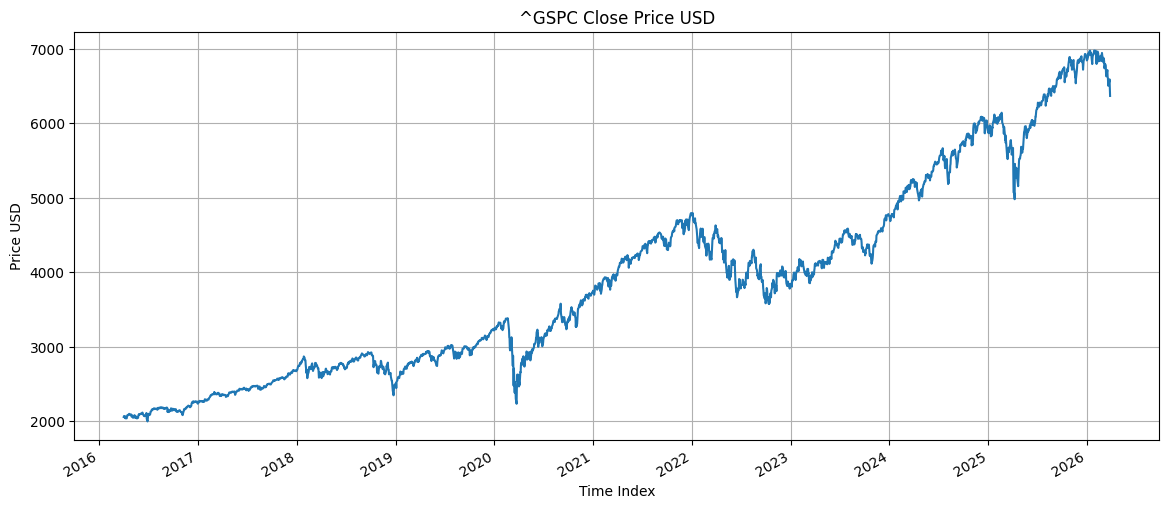

In [4]:
prices.plot(figsize=(14, 6), title=f"{SYMBOL} Close Price USD")
plt.ylabel("Price USD")
plt.xlabel("Time Index")
plt.grid()
plt.show()

In [5]:
returns = prices.pct_change().fillna(0)
display(returns.sample(10))

,Close
Date,
2025-05-16,0.007005
2019-03-20,-0.002944
2016-05-17,-0.009411
2025-08-27,0.002391
2022-03-04,-0.007934
2023-04-25,-0.015811
2024-03-19,0.005649
2024-02-15,0.005821
2025-12-08,-0.003477


### **[1. Simple Moving Average (SMA)](https://medium.com/@alexzap922/768016bc493b)**

> Performance of Multi-Window Simple Moving Average (SMA) Strategies: A Backtesting Comparison of Risk-Adjusted Returns, Volatility, and Drawdowns

In [6]:
# windows to test
windows = [10, 20, 50, 100, 200]

results = {} # performance metrics
equity_curves = {} # cumulative returns
drawdowns = {} # drawdowns
volatility = {} # volatility

In [7]:
for w in windows:
  sma = prices.rolling(w).mean() #the w-day simple moving average.

  signal = (prices > sma).astype(int) #trend signal
  position = signal.shift(1).fillna(0)

  strat_ret = position * returns
  equity = (1 + strat_ret).cumprod()

  # drawdown
  peak = equity.cummax()
  dd = (equity - peak) / peak

  # volatility
  vol = strat_ret.rolling(w).std() * np.sqrt(252)

  equity_curves[w] = equity
  drawdowns[w] = dd
  volatility[w] = vol

  ann_return = equity.iloc[-1] ** (252/len(equity)) - 1
  ann_vol = strat_ret.std() * np.sqrt(252)
  sharpe = ann_return / ann_vol if ann_vol != 0 else 0
  max_dd = dd.min()

  results[w] = {
    "Total Return": equity.iloc[-1] - 1,
    "Annual Return": ann_return,
    "Volatility": ann_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd
  }

perf = pd.DataFrame(results).T
display(perf)

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown
10,0.900554,0.066512,0.106573,0.624095,-0.210163
20,1.054616,0.074880,0.103993,0.720051,-0.180710
50,0.949826,0.069253,0.104884,0.660278,-0.213128
100,1.101586,0.077320,0.110105,0.702237,-0.193383
200,1.045881,0.074421,0.114429,0.650371,-0.196701


#### **Cumulative Returns of Multi-SMA Strategies**

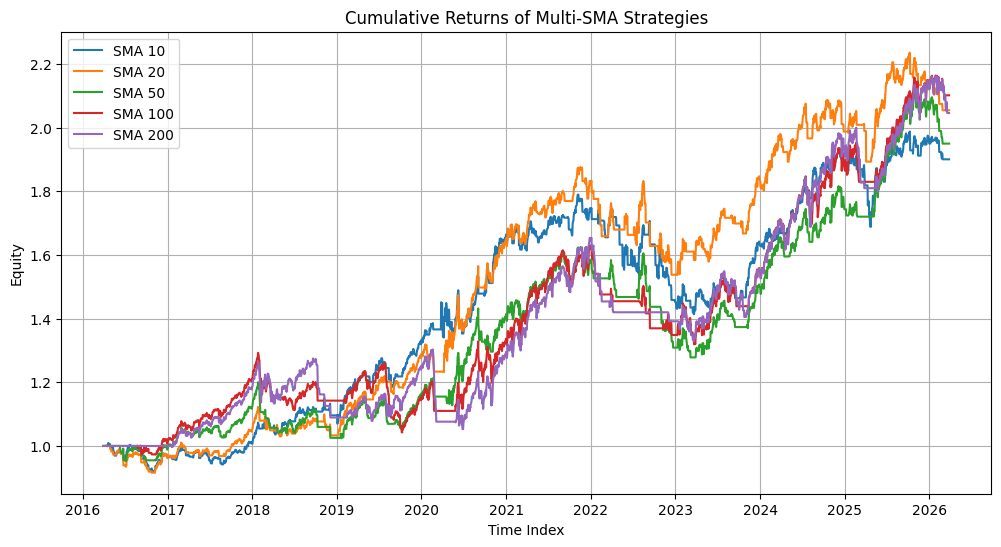

In [8]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(equity_curves[w], label=f"SMA {w}")

plt.title("Cumulative Returns of Multi-SMA Strategies")
plt.ylabel("Equity")
plt.xlabel("Time Index")
plt.legend()
plt.grid(True)

plt.show()

#### **Drawdowns of Multi-SMA Strategies**

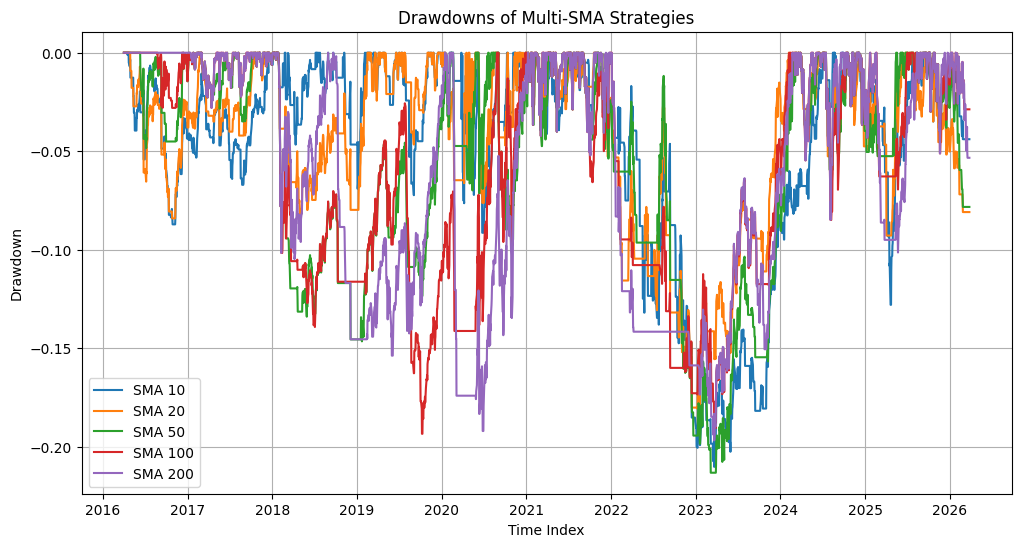

In [9]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(drawdowns[w], label=f"SMA {w}")

plt.title("Drawdowns of Multi-SMA Strategies")
plt.ylabel("Drawdown")
plt.xlabel("Time Index")
plt.legend()
plt.grid(True)

plt.show()

#### **Rolling Volatility of SMA**

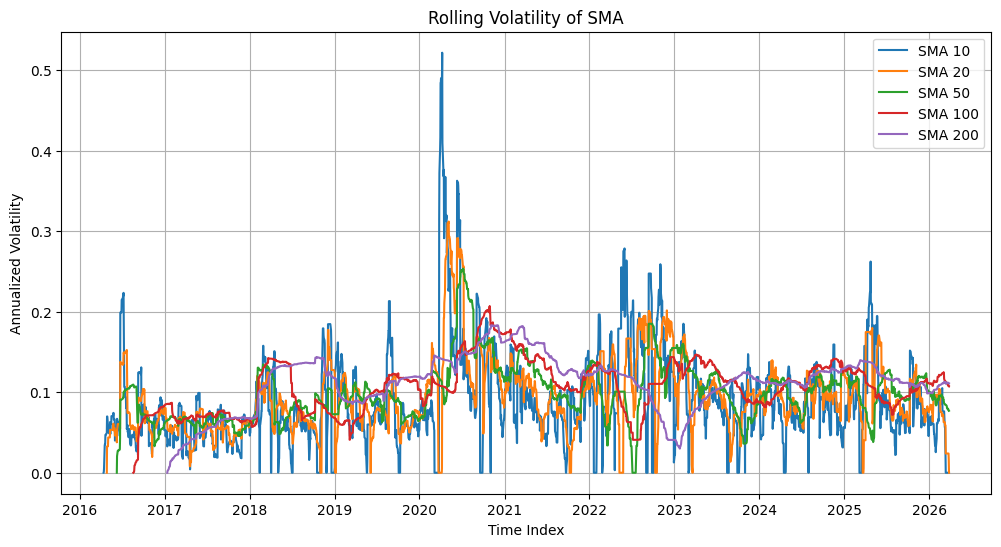

In [10]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(volatility[w], label=f"SMA {w}")

plt.title("Rolling Volatility of SMA")
plt.ylabel("Annualized Volatility")
plt.xlabel("Time Index")
plt.legend()
plt.grid(True)

plt.show()

#### **Multi-Window SMA Total Returns, Sharpe Ratio, and Volatility**

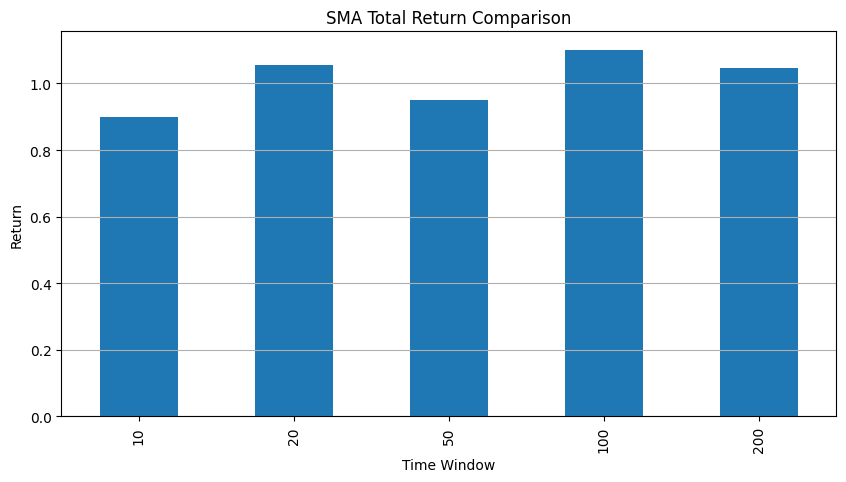

In [11]:
perf["Total Return"].plot.bar(figsize=(10,5))
plt.title("SMA Total Return Comparison")
plt.ylabel("Return")
plt.xlabel("Time Window")
plt.grid(axis='y')
plt.show()

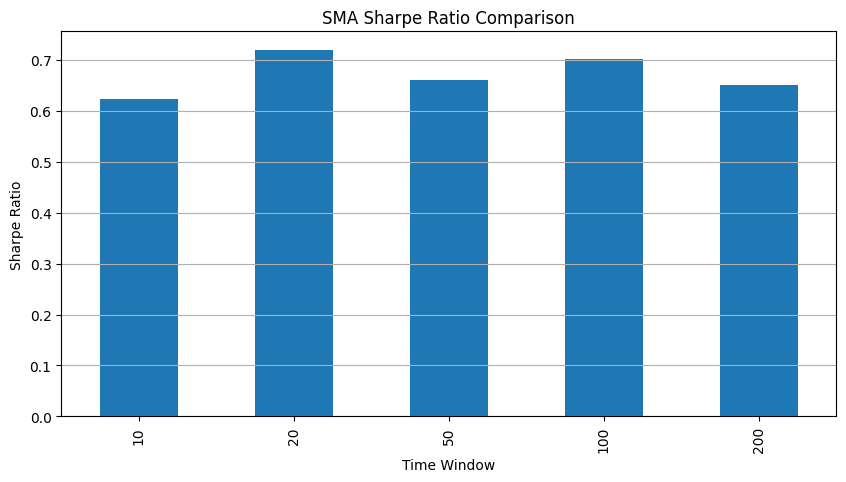

In [12]:
perf["Sharpe"].plot.bar(figsize=(10,5))
plt.title("SMA Sharpe Ratio Comparison")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Time Window")
plt.grid(axis='y')
plt.show()

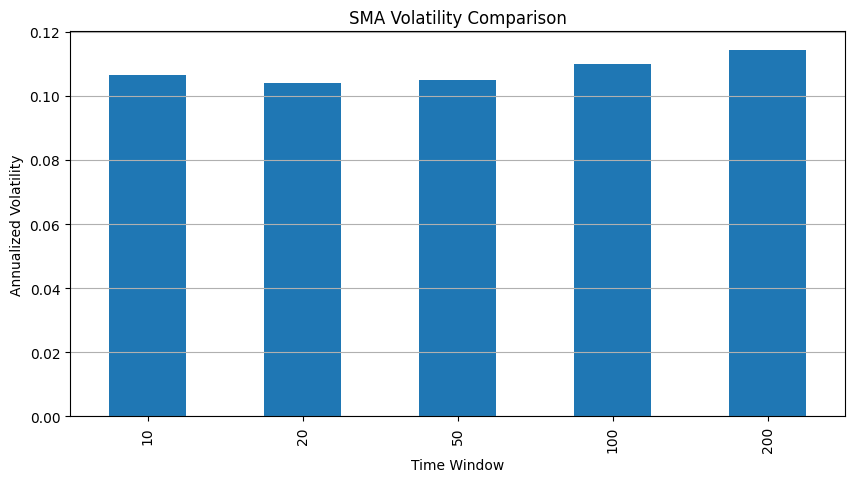

In [13]:
perf["Volatility"].plot.bar(figsize=(10,5))
plt.title("SMA Volatility Comparison")
plt.ylabel("Annualized Volatility")
plt.xlabel("Time Window")
plt.grid(axis='y')
plt.show()

In [14]:
display(perf.round(3))

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown
10,0.901,0.067,0.107,0.624,-0.210
20,1.055,0.075,0.104,0.720,-0.181
50,0.950,0.069,0.105,0.660,-0.213
100,1.102,0.077,0.110,0.702,-0.193
200,1.046,0.074,0.114,0.650,-0.197


In [15]:
perf_sma = perf.round(3)
perf_sma['MA'] = 'SMA'
perf_sma['Window'] = perf_sma.index
display(perf_sma)

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown,MA,Window
10,0.901,0.067,0.107,0.624,-0.210,SMA,10
20,1.055,0.075,0.104,0.720,-0.181,SMA,20
50,0.950,0.069,0.105,0.660,-0.213,SMA,50
100,1.102,0.077,0.110,0.702,-0.193,SMA,100
200,1.046,0.074,0.114,0.650,-0.197,SMA,200


### **[2. Weighted Moving Average (WMA)](https://medium.com/@alexzap922/fc47754f5d53)**

> Performance of Multi-Window **Weighted Moving Average (WMA)** Strategies: A Backtesting Comparison of Risk-Adjusted Returns, Volatility, and Drawdowns

In [16]:
# windows to test
windows = [10, 20, 50, 100, 200]

results = {} # performance metrics
equity_curves = {} # cumulative returns
drawdowns = {} # drawdowns
volatility = {} # volatility

In [17]:
def WMA(series, window):
  weights = np.arange(1, window + 1)
  return series.rolling(window).apply(
    lambda x: np.dot(x, weights) / weights.sum(),
    raw=True
  )

for w in windows:
  wma = WMA(prices, w)

  signal = (prices > wma).astype(int)
  position = signal.shift(1).fillna(0)

  strat_ret = position * returns
  equity = (1 + strat_ret).cumprod()

  peak = equity.cummax()
  dd = (equity - peak) / peak

  vol = strat_ret.rolling(w).std() * np.sqrt(252)

  equity_curves[w] = equity
  drawdowns[w] = dd
  volatility[w] = vol

  ann_return = equity.iloc[-1] ** (252/len(equity)) - 1
  ann_vol = strat_ret.std() * np.sqrt(252)
  sharpe = ann_return / ann_vol if ann_vol != 0 else 0
  max_dd = dd.min()

  results[w] = {
      "Total Return": equity.iloc[-1] - 1,
      "Annual Return": ann_return,
      "Volatility": ann_vol,
      "Sharpe": sharpe,
      "Max Drawdown": max_dd
  }

perf_wma = pd.DataFrame(results).T
display(perf_wma)

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown
10,0.720988,0.055950,0.108366,0.516307,-0.213427
20,0.820928,0.061944,0.105274,0.588411,-0.188931
50,1.219449,0.083231,0.103995,0.800335,-0.195500
100,0.851052,0.063693,0.106652,0.597206,-0.167701
200,1.086318,0.076532,0.111605,0.685743,-0.219340


#### **Cumulative Returns of Multi-Window WMA Strategies**

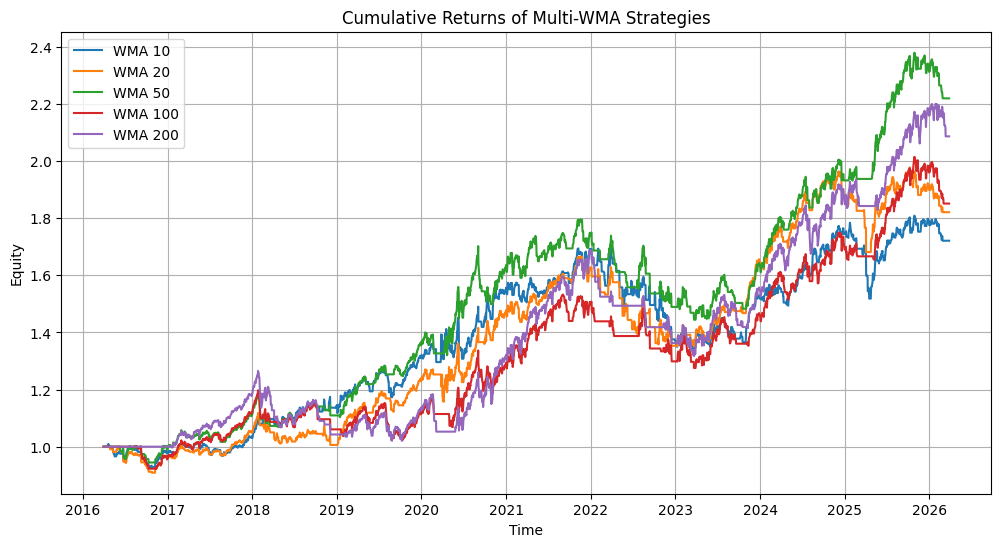

In [18]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(equity_curves[w], label=f"WMA {w}")

plt.title("Cumulative Returns of Multi-WMA Strategies")
plt.ylabel("Equity")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.show()

#### **Drawdowns of Multi-Window WMA Strategies**

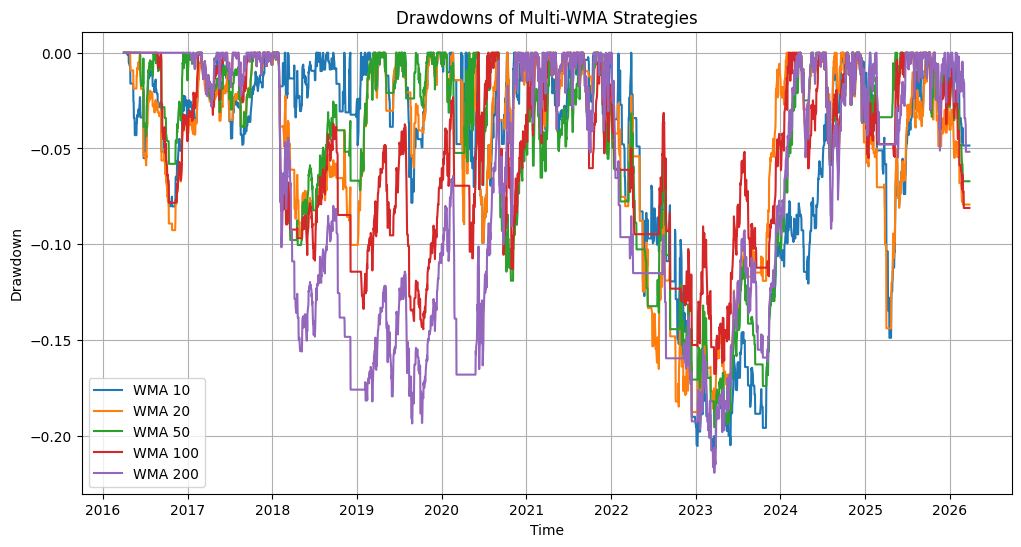

In [19]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(drawdowns[w], label=f"WMA {w}")

plt.title("Drawdowns of Multi-WMA Strategies")
plt.ylabel("Drawdown")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.show()

#### **Rolling Volatility of Multi-Window WMA Strategies**

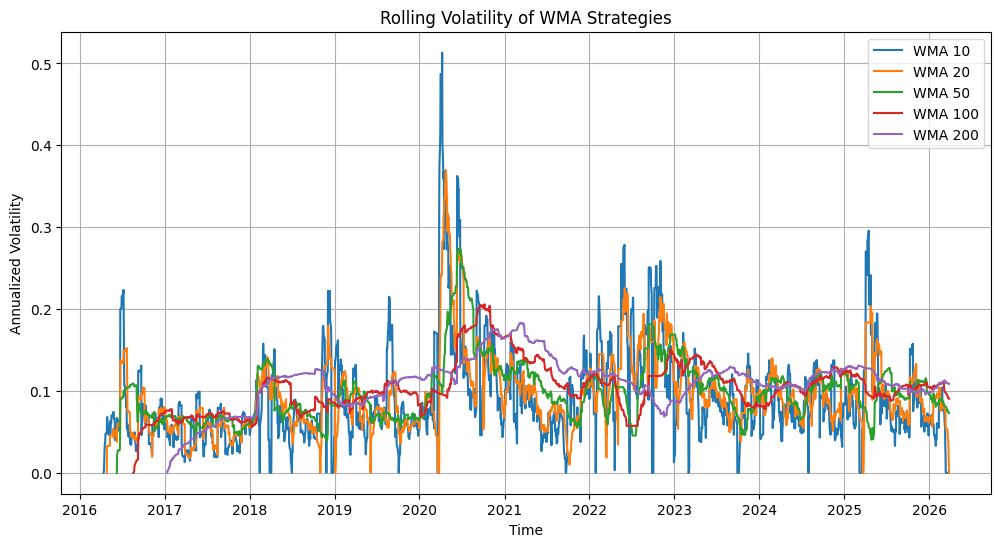

In [20]:
plt.figure(figsize=(12,6))

for w in windows:
  plt.plot(volatility[w], label=f"WMA {w}")

plt.title("Rolling Volatility of WMA Strategies")
plt.ylabel("Annualized Volatility")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.show()

#### **Multi-Window WMA Total Returns, Sharpe Ratio, and Volatility**

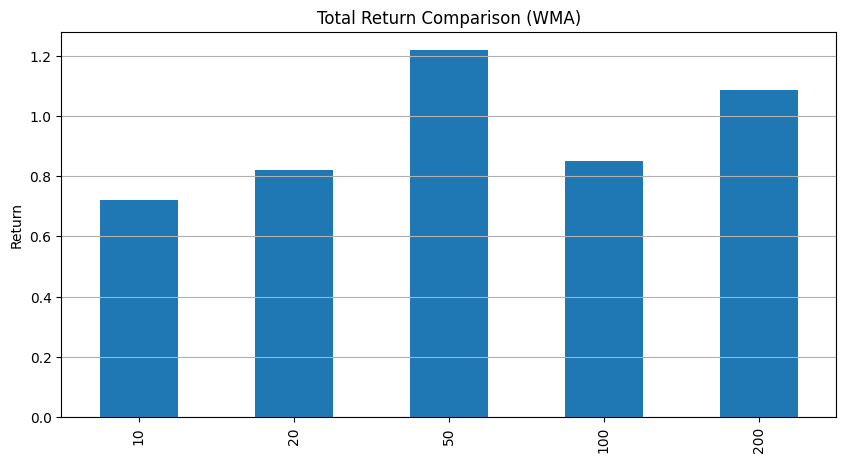

In [21]:
perf_wma["Total Return"].plot.bar(figsize=(10,5))
plt.title("Total Return Comparison (WMA)")
plt.ylabel("Return")
plt.grid(axis='y')
plt.show()

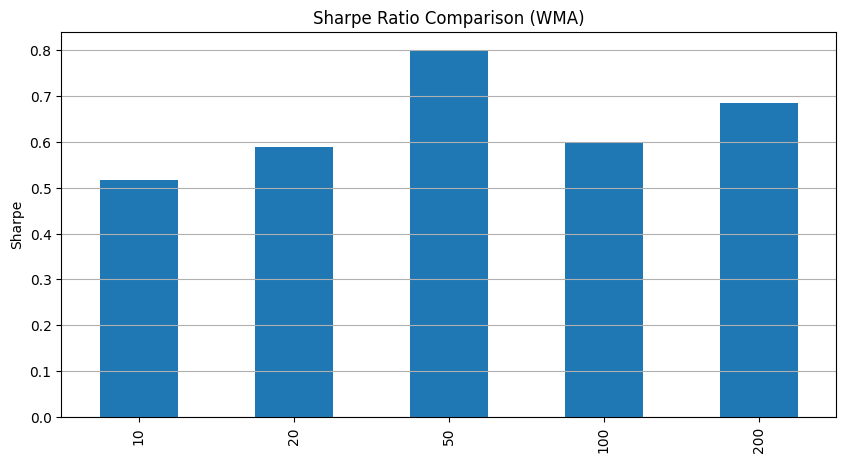

In [22]:
perf_wma["Sharpe"].plot.bar(figsize=(10,5))
plt.title("Sharpe Ratio Comparison (WMA)")
plt.ylabel("Sharpe")
plt.grid(axis='y')
plt.show()

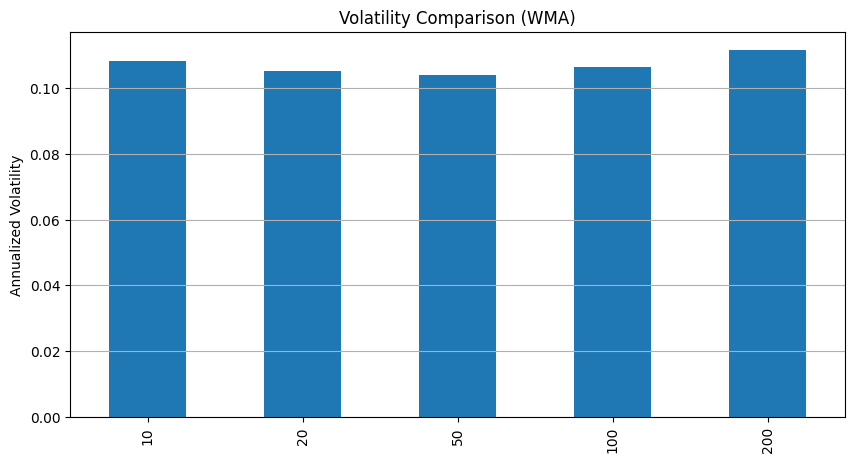

In [23]:
perf_wma["Volatility"].plot.bar(figsize=(10,5))
plt.title("Volatility Comparison (WMA)")
plt.ylabel("Annualized Volatility")
plt.grid(axis='y')
plt.show()

#### **WMA Performance**

In [24]:
display(perf_wma.round(3))

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown
10,0.721,0.056,0.108,0.516,-0.213
20,0.821,0.062,0.105,0.588,-0.189
50,1.219,0.083,0.104,0.800,-0.196
100,0.851,0.064,0.107,0.597,-0.168
200,1.086,0.077,0.112,0.686,-0.219


In [25]:
perf_wma['WMA'] = 'WMA'
perf_wma['Window'] = perf_wma.index

perf_combined = pd.DataFrame()
perf_combined = pd.concat([perf_sma, perf_wma])
perf_combined.reset_index(drop=True, inplace=True)
perf_combined['MA'] = perf_combined['MA'].fillna(perf_combined['WMA'])
perf_combined = perf_combined.drop(columns=['WMA'])
display(perf_combined)

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown,MA,Window
0,0.901000,0.067000,0.107000,0.624000,-0.210000,SMA,10
1,1.055000,0.075000,0.104000,0.720000,-0.181000,SMA,20
2,0.950000,0.069000,0.105000,0.660000,-0.213000,SMA,50
3,1.102000,0.077000,0.110000,0.702000,-0.193000,SMA,100
4,1.046000,0.074000,0.114000,0.650000,-0.197000,SMA,200
5,0.720988,0.055950,0.108366,0.516307,-0.213427,WMA,10
6,0.820928,0.061944,0.105274,0.588411,-0.188931,WMA,20
7,1.219449,0.083231,0.103995,0.800335,-0.195500,WMA,50
8,0.851052,0.063693,0.106652,0.597206,-0.167701,WMA,100
9,1.086318,0.076532,0.111605,0.685743,-0.219340,WMA,200


In [26]:
pivot_return = perf_combined.pivot(index='Window', columns='MA', values='Total Return')
pivot_sharpe = perf_combined.pivot(index='Window', columns='MA', values='Sharpe')
pivot_vol = perf_combined.pivot(index='Window', columns='MA', values='Volatility')

#### **SMA vs WMA Total Return**

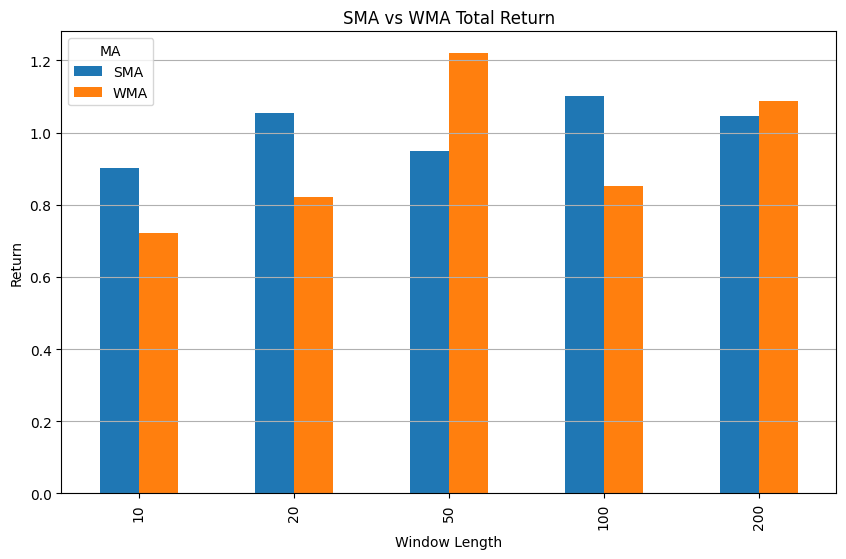

In [27]:
pivot_return.plot.bar(figsize=(10,6))

plt.title("SMA vs WMA Total Return")
plt.ylabel("Return")
plt.xlabel("Window Length")
plt.grid(axis='y')

plt.show()

#### **SMA vs WMA Sharpe Ratio**

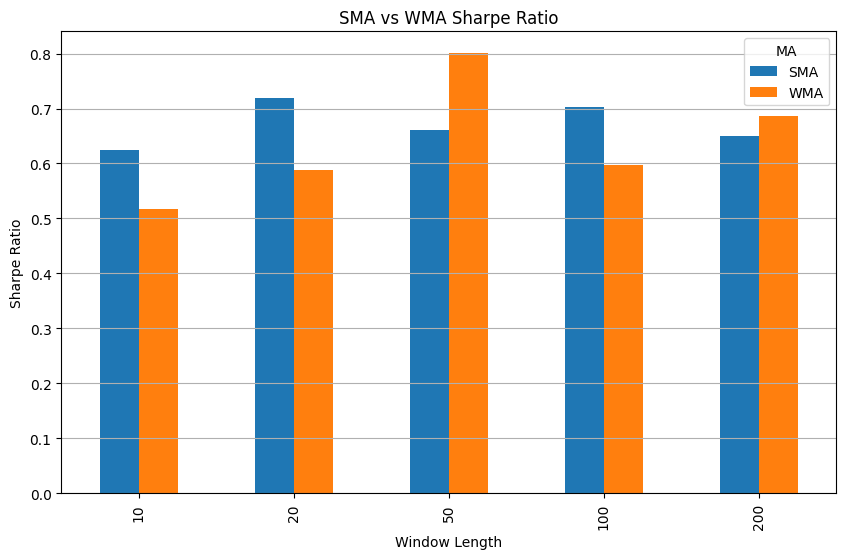

In [28]:
pivot_sharpe.plot.bar(figsize=(10,6))

plt.title("SMA vs WMA Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Window Length")
plt.grid(axis='y')

plt.show()

#### **SMA vs WMA Volatility**

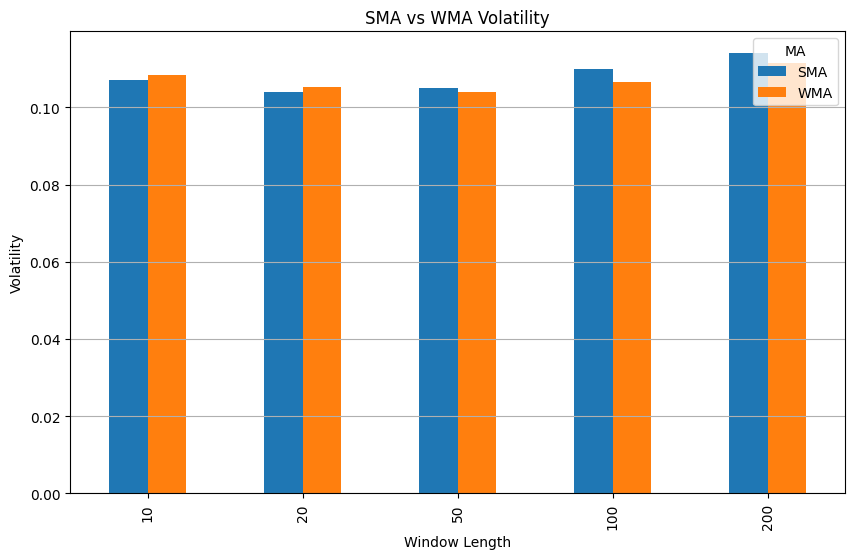

In [29]:
pivot_vol.plot.bar(figsize=(10,6))

plt.title("SMA vs WMA Volatility")
plt.ylabel("Volatility")
plt.xlabel("Window Length")
plt.grid(axis='y')

plt.show()